<font size='5'><h1 ><center> **Plants Identification by Deep Learning**</center></h1></font>

<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#acces">Introduction</a></li>
        <li><a href="#acces">Acces files in drive</a></li>
        <li><a href="#Preprocess_data">Data preprocessing and exploring </a></li>
        <li><a href="#modeling">Modeling</a></li>
        <li><a href="#mevaluation">Evaluation</a></li>
        <li><a href="#prediction">Prediction</a></li>
    </ol>
</div>
<br>

### **Introduction**

<font size='3'>"Automated species identification was presented 15 years ago as a challenging but very promising solution for the development of new research activities in Taxonomy, Biology or Ecology. However, identifying a plant for a botanist means associating a scientific name to an individual plant. More precisely, that means assigning that individual plant to a group, called a taxon. Such taxon had a name selected according to a set of rules. The delimitation of taxa and the scientific names applying to them are the result of a process called taxonomy (or systematics)".

Our project aims to create a solution that can identify a plant in an automated way. so I’m going to implement full CNN from scratch in Keras with a TensorFlow backend. This implementation will be performed on a dataset of five different kind flower. These flowers are daisy, dandelion, rose, sunflower and tulip.<font>

# Memory Information

In [1]:
import psutil
def get_size(bytes, suffix="B"):
    factor = 1024
    for unit in ["", "K", "M", "G", "T", "P"]:
        if bytes < factor:
            return f"{bytes:.2f}{unit}{suffix}"
        bytes /= factor
print("="*40, "Memory Information", "="*40)
svmem = psutil.virtual_memory()
print(f"Total: {get_size(svmem.total)}") ; print(f"Available: {get_size(svmem.available)}")
print(f"Used: {get_size(svmem.used)}") ; print(f"Percentage: {svmem.percent}%")

======================================== Memory Information ========================================
Total: 7.62GB
Available: 6.71GB
Used: 933.15MB
Percentage: 12.0%


# GPU Information

In [2]:
! nvidia-smi

Sat Nov 15 12:35:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.10              Driver Version: 581.29         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P0             25W /   80W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### **Access files in Drive**
> We can access files in Drive in a number of ways, including: Mounting our Google Drive in the runtime's virtual machine using an authorization code




In [ ]:
from google.colab import drive 
drive.mount('/gdrive')
%cd /gdrive

#### Load required libraries

In [3]:
import numpy as np # linear algebra
import pandas as pd  # data processing
import os #  to interact with files using there paths
from sklearn.datasets import load_files

### Loading the Data

In [4]:
#The path of our data on drive
data_dir =  '/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers'
 
#Loading our Data
data = load_files(data_dir)

### **Data Preprocessing and exploring**

In [5]:
folders = os.listdir(data_dir)
print(folders)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


#### We have one folder for each flower classe or type. We are going to load it into two numpy arrays as follows :    

- X - filenames (Training data)
- y - flower names(Target labels)

In [6]:
X = np.array(data['filenames'])
y = np.array(data['target'])
labels = np.array(data['target_names'])
 
# How the arrays look like?
print('Data files - ',X)
print('Target labels - ',y)

Data files -  ['/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers/sunflower/7176729016_d73ff2211e.jpg'
 '/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers/dandelion/18385846351_3a2bf60427_n.jpg'
 '/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers/dandelion/98992760_53ed1d26a9.jpg'
 ...
 '/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers/dandelion/7184780734_3baab127c2_m.jpg'
 '/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers/sunflower/10386540106_1431e73086_m.jpg'
 '/mnt/d/7th Semester/Data Mining/Project/Plants_Identification_DL_SI-master/data/flowers/sunflower/164670176_9f5b9c7965.jpg']
Target labels -  [3 1 1 ... 1 3 3]


#### As you can see, numbers in the **Target labels - [4 4 2 ... 1 2 3]** are corresponding to class label. We need to change them to a vector of 5 elements ( 5 classes )

### Remove .pyc or .py files
> If you explore our data closely, you will see some other files that are not images with the '.pyc' and '.py' extensions, especially in the dandelion class. So, we have to remove them. 

> Don't worry, you may not want to do it that way. however, you can simply work with files whose names end with the extension .jpg using the **endswith ('jpg')** function properly.

In [7]:
# Remove .pyc or .py files
pyc_file_pos = (np.where(file==X) for file in X if file.endswith(('.pyc','.py')))
for pos in pyc_file_pos:
    X = np.delete(X,pos)
    y = np.delete(y,pos)
    
print('Number of training files : ', X.shape[0])
print('Number of training targets : ', y.shape[0])

Number of training files :  4317
Number of training targets :  4317


### Load the images
> We only have the filenames in X. So, it's time to load the images from the filename with an appropriate size which ensures a small number of parameters to minimize runtime as much as possible during the training step and save them to X. Here we are going to use (150, 150) as the image size for the previous reasons.


In [8]:
from keras.preprocessing.image import img_to_array, load_img

def convert_img_to_arr(file_path_list):
    arr = []
    #size=64,64
    img_width, img_height = 150,150
    for file_path in file_path_list:
        img = load_img(file_path, target_size = (img_width, img_height))
        img = img_to_array(img)
        arr.append(img)
        #arr.append(cv2.resize(img,size))
    return arr
 
X = np.array(convert_img_to_arr(X))
print(X.shape) 
print('First training item : ',X[0])

2025-11-15 12:37:25.672518: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-15 12:37:25.926291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763190446.009493     843 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763190446.035637     843 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-15 12:37:26.246271: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

(4317, 150, 150, 3)
First training item :  [[[101. 114.   8.]
  [ 33.  38.  18.]
  [ 23.  29.  15.]
  ...
  [  1. 102. 190.]
  [  4. 103. 188.]
  [ 13.  74. 128.]]

 [[ 31.  39.  15.]
  [ 23.  32.  15.]
  [ 23.  27.  12.]
  ...
  [  0.  47. 106.]
  [  8.  72. 116.]
  [ 24.  77. 121.]]

 [[ 54.  62.  15.]
  [ 28.  32.  17.]
  [ 29.  32.  21.]
  ...
  [  0.  55. 103.]
  [  5.  34.  66.]
  [  5.  31.  64.]]

 ...

 [[ 99.  96.  27.]
  [ 82.  84.  21.]
  [ 72.  68.  33.]
  ...
  [ 94. 112. 134.]
  [ 88. 101. 118.]
  [ 78.  89. 107.]]

 [[114. 107.  17.]
  [109.  99.  40.]
  [108.  84.  60.]
  ...
  [ 87. 105. 129.]
  [ 83. 103. 130.]
  [ 86.  97. 115.]]

 [[166. 157.  56.]
  [130. 112.  36.]
  [184. 178.  28.]
  ...
  [ 32.  32.  30.]
  [ 64.  75.  81.]
  [ 83.  95. 117.]]]


#### **Few Take Aways**
#### Note that the shape of training data is **(4323, 150, 150, 3)**
#####  
 
-   **4323** is the **number** of training items or files,
-   **(150,150)** is the **target size** or image size provided while loading image
-   **3** refers to the **depth** for colored images ( RGB channels ).

### Take a look at some pictures

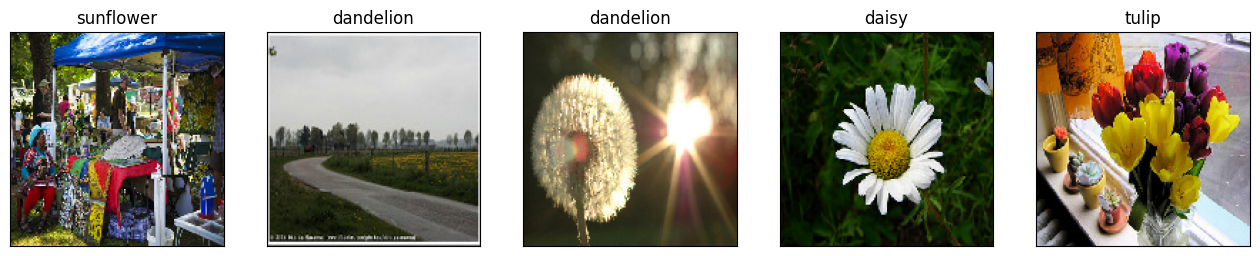

In [9]:
#Let's look at first 5 training data.

import matplotlib.pyplot as plt
 
fig = plt.figure(figsize = (16,9))
for i in range(5):
    ax = fig.add_subplot(1,5,i+1,xticks=[],yticks=[])
    ax.imshow((X[i].astype(np.uint8)))
    plt.title(folders[y[i]])

Spectacular! The flowers are so beautiful :)

### Why we need to [rescal](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html) our data ?
> rescale is a value by which we will multiply the data before any other processing. Our original images consist in RGB coefficients in the 0-255, but such values would be too high for our models to process (given a typical learning rate), so we target values between 0 and 1 instead by scaling with a 1/255. factor. So all values in X will lie within 0 to 1 !



In [10]:
# Let's resize or rescale training data
X = X.astype('float32')/255
 
# Let's confirm the number of classes :) 
no_of_classes = len(np.unique(y))
no_of_classes

5


> Great! we will predict the flowers of five classes



In [11]:
y

array([3, 1, 1, ..., 1, 3, 3])

 ### Let's converts a class vector (integers) to binary class matrix:
**Arguments:**
- **y**	class vector to be converted into a matrix (integers from 0 to no_of_classes).
- **no_of_classes** total number of classes.
- **dtype**	The data type expected by the input. Default: 'float32'.

**Returns:**
- A binary matrix representation of the input. The classes axis is placed last. [for more...](https://www.tensorflow.org/versions/r1.15/api_docs/python/tf/keras/utils/to_categorical)

In [12]:
from tensorflow.keras.utils import to_categorical

y = np.array(to_categorical(y, num_classes=no_of_classes))
y[0]

array([0., 0., 0., 1., 0.])

### Split the data into train, test and valid subsets
> Here we are going to split our dataset into **80% train**, **10% validation**, and **10% test**.


In [13]:
from sklearn.model_selection import train_test_split

# let's splite the data into subsets and explore their shapes !

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print('The test Data Shape ', X_test.shape[0])
 
X_test, X_valid, y_test, y_valid = train_test_split(X_test,y_test, test_size = 0.5)
print('The training Data Shape ', X_valid.shape[0])

The test Data Shape  864
The training Data Shape  432


In [14]:
print('The train Data Shape ', X_train.shape[1:])

The train Data Shape  (150, 150, 3)


> (150, 150, 3) refers to the shape of the data (images) that will be fed into our CNN



### **CNN Implementation**
> This is an image that shows how our CNN architecture looks like :



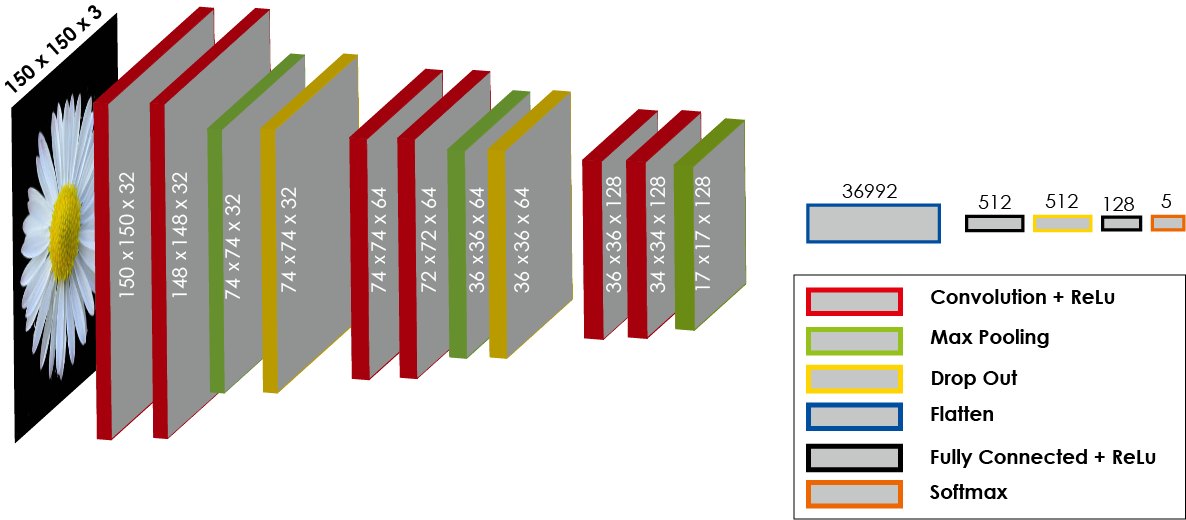

### Import the necessary libraries
> As you can see here, Keras library allows us to import the different functions for building our CNN architecture (Conv2D, MaxPooling2D, Dense, Flatten Dropout.




In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau


### CNN Architecture
I will be using Sequential method as I am creating a sequential model. **Sequential model means that all the layers of the model will be arranged in sequence**, then i will add:
> * 2 x convolution layer of 32 channel of 3x3 kernal and same padding;
* 1 x maxpool layer of 2x2 pool size;
* 1 x droupt with a frequency of rate equal to 0.25;
* 2 x convolution layer of 64 channel of 3x3 kernal and same padding:
* 1 x maxpool layer of 2x2 pool size 
* 1 x droupt with a frequency of rate equal to 0.25;
* 2 x convolution layer of 128 channel of 3x3 kernal and same padding;
* 1 x maxpool layer of 2x2 pool size;
* 1 x flatten;
* 1 x dense layer of 512
* 1 x dropout set at 0.5
* 1 x dense layer of 128
* 1 x Dense Softmax layer of 5 units

=> **Dropout** is a technique of regularisation which helps us to prevent _**overfitting**_.

If you noticed, I also add **ReLu** (Rectified Linear Unit) activation to each layers so that all the negative values are not passed to the next layer:)


In [16]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', input_shape=X_train.shape[1:], activation='relu', name='Conv2D_1'))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', name='Conv2D_2'))
model.add(MaxPool2D(pool_size=(2,2), name='Maxpool_1'))
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', name='Conv2D_3'))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', name='Conv2D_4'))
model.add(MaxPool2D(pool_size=(2,2), name='Maxpool_2'))
model.add(Dropout(0.25))
    
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu', name='Conv2D_5'))
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', name='Conv2D_6'))
model.add(MaxPool2D(pool_size=(2,2), name='Maxpool_3'))

model.add(Flatten())
model.add(Dense(units=512, activation='relu', name='Dense_1'))
model.add(Dropout(0.5))
model.add(Dense(units=128, activation='relu', name='Dense_2'))
model.add(Dense(units=no_of_classes, activation='softmax', name='Output'))

/home/prajwal/tf-project/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763190467.325012     843 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### Model Summary

In [17]:
# Getting the summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_1 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Maxpool_1 (MaxPooling2D)        │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_3 (Conv2D)               │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_4 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Maxpool_2 (MaxPooling2D)        │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_5 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_6 (Conv2D)               │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Maxpool_3 (MaxPooling2D)        │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,293,733 (73.60 MB)

 Trainable params: 19,293,733 (73.60 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model
> I will be using the **RMSprop** optimizer to Maintain a moving (updated) average of the square of the gradients during training, here, in this case, it is fixed at 0.001. If our training bounces a lot off epochs, we need to reduce the learning rate to maintain a moving average.




In [18]:
# prefer tensorflow.keras imports
from tensorflow.keras.optimizers import RMSprop

# use learning_rate (not lr). decay is ignored/removed.
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


### Fitting the model
For callbacks, I employed:


>* **ModelCheckpoint :** Callback to save the model or model weights at certain frequencies (in this case, the model will be saved That only if the validation accuracy of the model at the present time is greater than that at the last time)
* **ReduceLRonPlateau :** Reduce learning rate when a performance metric has stopped improving (in this case, I have set the patience at 3, which means that the model will reduce the learning rate if it does not see any increase in the validation precision in 3 epochs)

   I am using **model.fit_generator** because I am using **ImageDataGenerator** to pass data to the model. I will pass the train and valid data to **fit_generator**. In **fit_generator**, **steps_per_epoch** will set the **batch_size** to pass training data to the model and **validation_steps** will do the same for validation data. These settings could be changed according to each system specifications.



In [19]:
import time
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau # Make sure ReduceLROnPlateau is imported!
# from keras.preprocessing.image import ImageDataGenerator # Ensure this is imported in an earlier cell!

# Time to train our model !
epochs = 500
batch_size=32

train_datagen = ImageDataGenerator(
    rotation_range=10, 
    zoom_range = 0.1, 
    width_shift_range=0.1,
    height_shift_range=0.1,  
    horizontal_flip=True)

test_datagen = ImageDataGenerator()

# ... (your ImageDataGenerator definitions remain the same) ...

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=batch_size,
    # ⭐️ ADD THIS PARAMETER:
   # class_mode='categorical' 
)

validation_generator = test_datagen.flow(
    X_valid, y_valid,
    batch_size=batch_size,
    # ⭐️ ADD THIS PARAMETER:
    #class_mode='categorical'
)

# ⭐️ CHANGE 1: Local file path
checkpointer = ModelCheckpoint(filepath = "PId_Best.h5", save_best_only = True, verbose = 1)
learning_rate_reduction=ReduceLROnPlateau(monitor='val_accuracy', patience = 3, verbose = 1, factor = 0.5, minlr = 0.00001)


start = time.time()

# let's get started !
# ⭐️ CHANGE 2: Use model.fit instead of model.fit_generator
history=model.fit(train_generator,
                               epochs=epochs,
                               validation_data = validation_generator,
                               verbose=1,
                               steps_per_epoch=len(X_train) // batch_size,
                               #validation_steps=len(X_valid) //batch_size,
                               callbacks=[checkpointer, learning_rate_reduction])

end = time.time()

duration = end - start
print ('\n This Model took %0.2f seconds (%0.1f minutes) to train for %d epochs'%(duration, duration/60, epochs) )

Epoch 1/500


I0000 00:00:1763190469.342641    1036 service.cc:148] XLA service 0x7f135c00e9b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763190469.342688    1036 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-11-15 12:37:49.394070: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763190469.555337    1036 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/107 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.1753 - loss: 5.0997 

I0000 00:00:1763190477.560603    1036 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.2438 - loss: 2.1034
Epoch 1: val_loss improved from None to 1.21309, saving model to PId_Best.h5


...

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7188 - loss: 0.5789 - val_accuracy: 0.7569 - val_loss: 0.6781 - learning_rate: 1.2500e-04
Epoch 31/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7823 - loss: 0.5710
Epoch 31: val_loss improved from 0.67814 to 0.67520, saving model to PId_Best.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7816 - loss: 0.5709 - val_accuracy: 0.7546 - val_loss: 0.6752 - learning_rate: 1.2500e-04
Epoch 32/500
  1/107 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7812 - loss: 0.6952
Epoch 32: val_loss improved from 0.67520 to 0.67398, saving model to PId_Best.h5



Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7812 - loss: 0.6952 - val_accuracy: 0.7477 - val_loss: 0.6740 - learning_rate: 1.2500e-04
Epoch 33/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7959 - loss: 0.5505
Epoch 33: val_loss did not improve from 0.67398
107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.7925 - loss: 0.5520 - val_accuracy: 0.7593 - val_loss: 0.7050 - learning_rate: 6.2500e-05
Epoch 34/500
  1/107 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6875 - loss: 0.7468
Epoch 34: val_loss did not improve from 0.67398
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.7468 - val_accuracy: 0.7616 - val_loss: 0.6775 - learning_rate: 6.2500e-05
Epoch 35/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7958 - loss: 0.5517
Epoch 35: val_loss did not improve from 0.67398

Epoch 35: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-0

107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8071 - loss: 0.5282 - val_accuracy: 0.7708 - val_loss: 0.6691 - learning_rate: 1.5625e-05
Epoch 42/500
  1/107 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8125 - loss: 0.5151
Epoch 42: val_loss improved from 0.66909 to 0.66867, saving model to PId_Best.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8125 - loss: 0.5151 - val_accuracy: 0.7708 - val_loss: 0.6687 - learning_rate: 1.5625e-05
Epoch 43/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8105 - loss: 0.5300
Epoch 43: val_loss did not improve from 0.66867
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.8091 - loss: 0.5222 - val_accuracy: 0.7755 - val_loss: 0.6713 - learning_rate: 1.5625e-05
Epoch 44/500
  1/107 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8438 - loss: 0.3706
Epoch 44: val_loss did not improve from 0.66867
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8438 - loss: 0.3706 - val_accuracy: 0.7731 - val_loss: 0.6716 - learning_rate: 1.5625e-05
Epoch 45/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8076 - loss: 0.5106
Epoch 45: val_loss did not improve from 0.66867
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.8077 - loss: 0.5130 - val_accuracy: 0.7685 - val_loss: 0.6889 - learning_rate: 1.5625e-05
Epoch 

### Model Evaluation

In [20]:
(eval_loss, eval_accuracy) = model.evaluate(  
     X_test, y_test, batch_size=batch_size, verbose=2)
 
print("Accuracy: {:.2f}%".format(eval_accuracy * 100))  
print("Loss: {}".format(eval_loss))

14/14 - 1s - 83ms/step - accuracy: 0.7338 - loss: 0.7356
Accuracy: 73.38%
Loss: 0.7355850338935852


### Acuuracy and Loss graphs

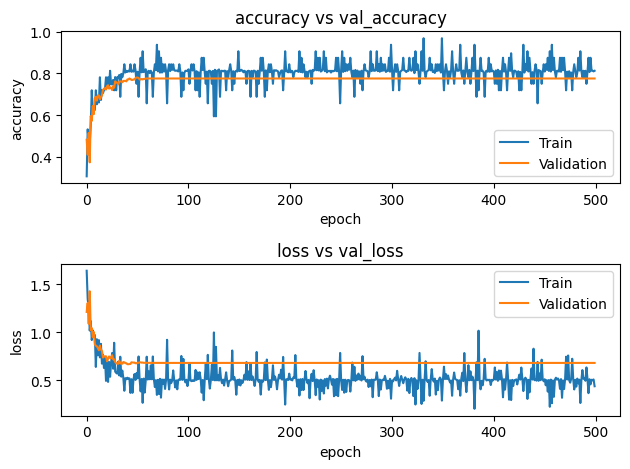

In [21]:
# Let's visualize the train/validation loss and accuracy wrt epochs

import matplotlib.pyplot as plt 
def plot(history):
    plt.figure(1)
    #plt.figure(figsize=(10,10)) 
 
     # summarize history for accuracy  
 
    plt.subplot(211)  
    plt.plot(history.history['accuracy'])  
    plt.plot(history.history['val_accuracy'])  
    plt.title('accuracy vs val_accuracy')  
    plt.ylabel('accuracy')  
    plt.xlabel('epoch')  
    plt.legend(['Train', 'Validation'], loc='lower right')  
 
     # summarize history for loss  
 
    plt.subplot(212)  
    plt.plot(history.history['loss'])  
    plt.plot(history.history['val_loss'])  
    plt.title('loss vs val_loss')  
    plt.ylabel('loss')  
    plt.xlabel('epoch')  
    plt.legend(['Train', 'Validation'], loc='upper right')
    plt.tight_layout()
    plt.show()
 
# Finaly, let's call the plot function with the 'result' parameter 
 
plot(history)

#### **Few take aways**
> * From the Training and Validation Accuracy graph above, our model does not seem to be overfitted, which is great!
* Also, Our Training and Validation Loss graph above also indicates a good learning rate.



### Prediction
> Finally, let us test our model against more random samples from the test data !



14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


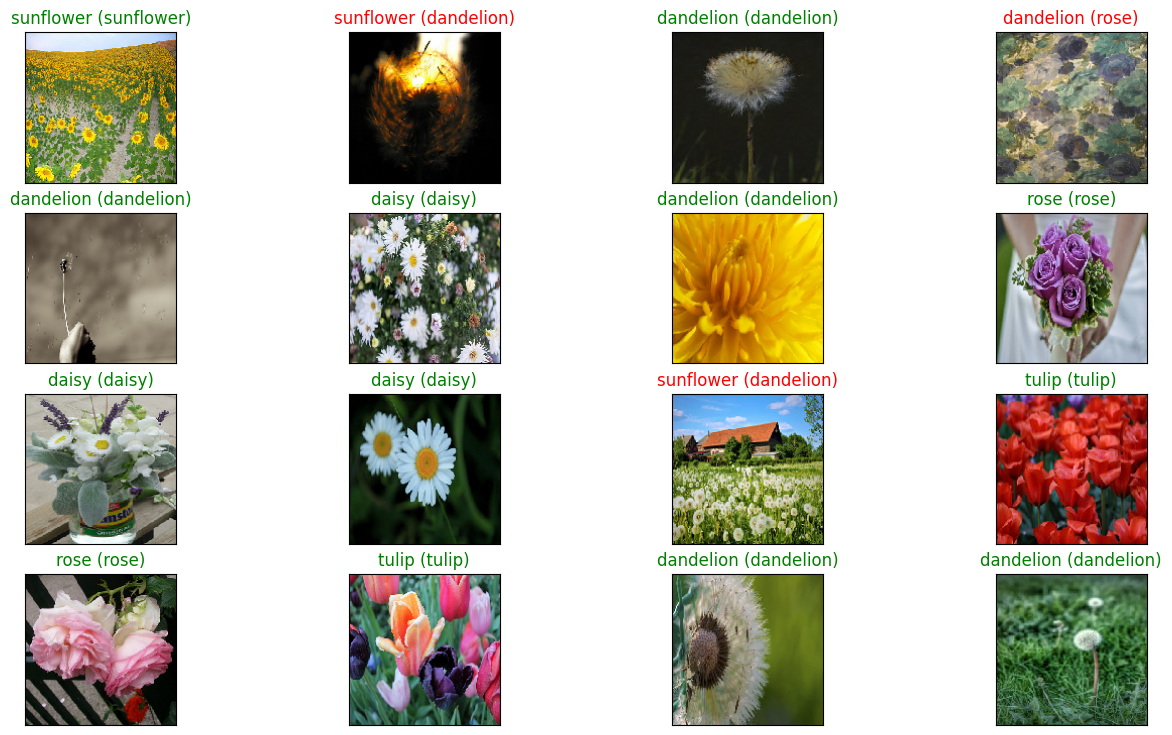

In [22]:
# Let's visualize some random test prediction.
def visualize_pred(y_pred):
# plot a random sample of test images, their predicted labels, and ground truth
    fig = plt.figure(figsize=(16, 9))
    for i, idx in enumerate(np.random.choice(X_test.shape[0], size=16, replace=False)):
        ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(X_test[idx]))
        pred_idx = np.argmax(y_pred[idx])
        true_idx = np.argmax(y_test[idx])
        ax.set_title("{} ({})".format(labels[pred_idx], labels[true_idx]),
                     color=("green" if pred_idx == true_idx else "red"))

visualize_pred(model.predict(X_test))

### Confusion matrix
I will plotting confusion matrix according to test datas. **0,1,2,3,4** values in this matrix means **daisies, dandelions, roses, sunflowers, tulips** respectively

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


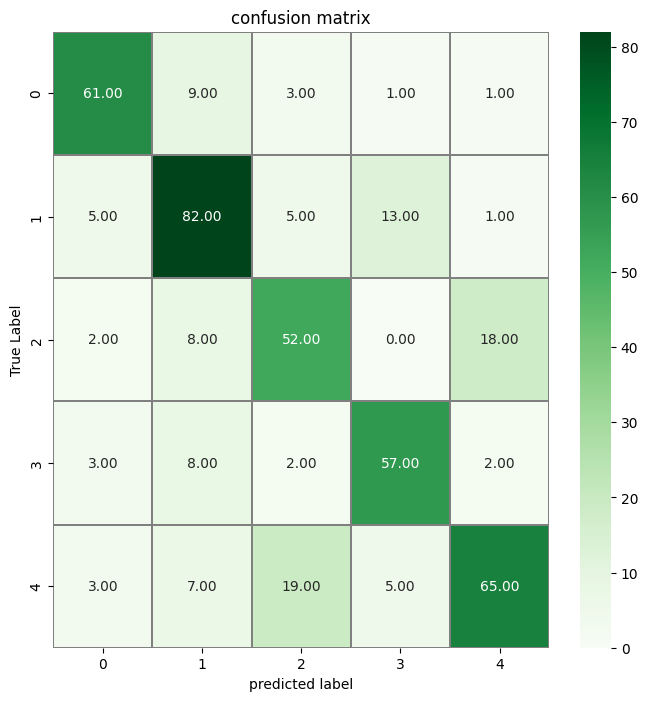

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
Y_true = np.argmax(y_test,axis = 1)
confusion_mtx = confusion_matrix(Y_true,Y_pred_classes)
f,ax = plt.subplots(figsize = (8,8))
sns.heatmap(confusion_mtx,annot=True,linewidths = 0.01,cmap="Greens",
            linecolor = "gray",fmt = ".2f",ax=ax
            )
plt.xlabel("predicted label")
plt.ylabel("True Label")
plt.title("confusion matrix")
plt.show()

### **Few Take aways:**
- The most difficult to detect the type of flower is **tulip**.
- The easiest to detect the type of flower is **daisy**.
- Our confusion matrix indicates that a lot of prediction errors came from distinguishing between **rose** and **tulip**.

### Loading the model
> Here we're gonna load our best model trained befor, then make some predictions with it !

In [24]:
from tensorflow import keras

my_model = keras.models.load_model("PId_Best.h5")


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


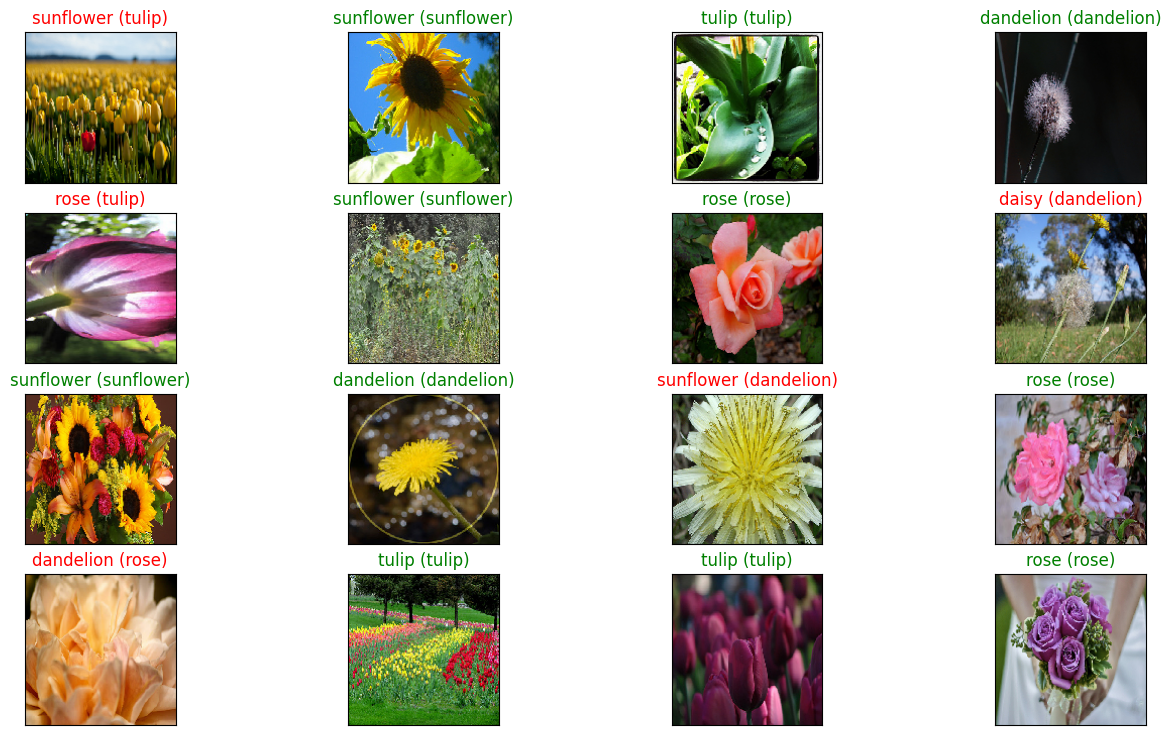

In [25]:
# Let's visualize some random test prediction.
def visualize_pred(y_pred):
# plot a random sample of test images, their predicted labels, and ground truth
    fig = plt.figure(figsize=(16, 9))
    for i, idx in enumerate(np.random.choice(X_test.shape[0], size=16, replace=False)):
        ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(X_test[idx]))
        pred_idx = np.argmax(y_pred[idx])
        true_idx = np.argmax(y_test[idx])
        ax.set_title("{} ({})".format(labels[pred_idx], labels[true_idx]),
                     color=("green" if pred_idx == true_idx else "red"))

visualize_pred(my_model.predict(X_test))

## **Conclusion**
The classification precision achieved is great! Considering the quality of data which have been impacted by some issues including :
- Images with noisy backgrounds;
- Multiple plant species appearing in the same image;
- The plant transforms morphologically during its growth... etc.

>This project can be considered quite successful. Of course, there is still much room for improvement. firstly, we can apply the [**Transfer Learning**](https://keras.io/guides/transfer_learning/) principe with advanced and popular architectures as VGG16 or ResNet-50 and train it from fine-tuned from pre-trained weights on the popular **ImageNet** dataset.


**Author : ZEKAOUI Nour Eddine** 

*   My [LinkedIn](https://www.linkedin.com/in/nour-eddine-zekaoui-ba43b1177/)
*   My [GitHub](https://github.com/zekaouinoureddine)



## **Thank you a lot for your interest** ☻

In [26]:
import tensorflow as tf
print("TF:", tf.__version__)
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))


TF: 2.18.1
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
import sys
print(sys.executable)


/home/prajwal/tf-project/.venv/bin/python
